# 04 — Practical significance and business impact

**Stage 6.** Translates the statistically significant result into
business terms: relative uplift, additional converters across the
user base, and an illustrative revenue scenario.


In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'marketing_AB.csv').exists():
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from src.eda import load_marketing_ab, conversion_rates
from src.inference import wald_ci_difference
df = load_marketing_ab(root / 'data' / 'marketing_AB.csv')
cr = conversion_rates(df).set_index('test_group')
x_ad, n_ad = cr.loc['ad', 'converted'], cr.loc['ad', 'users']
x_psa, n_psa = cr.loc['psa', 'converted'], cr.loc['psa', 'users']
p_ad, p_psa = x_ad / n_ad, x_psa / n_psa
diff = p_ad - p_psa
lo, hi = wald_ci_difference(p_ad, p_psa, n_ad, n_psa)
users = len(df)
print(f'relative uplift: {diff/p_psa:.1%}')
print(f'additional converters (all {users:,} users): {diff*users:,.0f}')
print(f'CI: [{lo*users:,.0f}, {hi*users:,.0f}]')

relative uplift: 43.1%
additional converters (all 588,101 users): 4,524
CI: [3,500, 5,548]


## 1. Business-wide impact with uncertainty

One number without a CI hides the risk. The interval answers:
*if the ad runs for the whole population, how many additional
converters should we expect?* (3.5K–5.5K).


(2000.0, 7000.0)

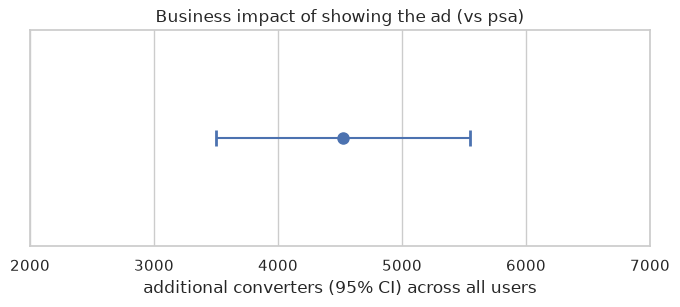

In [2]:
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.errorbar(x=[diff*users], y=[0], xerr=[[diff*users - lo*users],[hi*users - diff*users]],
            fmt='o', ms=8, color='#4C72B0', capsize=6, capthick=2)
ax.annotate(f'+{diff*users:,.0f} converters', xy=(diff*users, 0.12), ha='center', color='#4C72B0')
ax.set_yticks([])
ax.set_xlabel('additional converters (95% CI) across all users')
ax.set_title('Business impact of showing the ad (vs psa)')
ax.set_xlim(2000, 7000)

## 2. Illustrative revenue scenario

The dataset contains **no revenue/money column**, so revenue cannot
be read from the data: it is a deliberately declared scenario
(assumption: revenue per converter, RPC). Every row is a 'what if'.


In [3]:
rpc_values = [5, 10, 20]
rows = []
for rpc in rpc_values:
    rows.append({'revenue_per_converter': rpc,
                 'low (95% CI)': rpc * lo * users,
                 'point estimate': rpc * diff * users,
                 'high (95% CI)': rpc * hi * users})
rev = pd.DataFrame(rows).set_index('revenue_per_converter')
rev.index.name = 'RPC, currency units'
display(rev.round(0).astype(int))

,low (95% CI),point estimate,high (95% CI)
"RPC, currency units",,,
5,17499,22620,27741
10,34997,45239,55481
20,69995,90479,110963


## 3. Honest interpretation limits (statistics ≠ causation)

- **Observational cohort:** the campaign already ran; the comparison
  is association, not proof that showing the ad *causes* conversion.
- **Cost side is missing:** gains only; no ad spend, no marginal
  economics. A decision needs cost data.
- **Confounder warning:** `total_ads` correlates with both exposure
  and conversion; a rigorous causal design (randomisation or
  adjustment) is the follow-up this dataset cannot provide.
- **Synthetic data:** numbers are illustrative of the *method*; the
  absolute business figures are not a real company's P&L.

Resume takeaway: the decision pipeline (MDE → power → CI → business
scenario) is fully reproducible, the limits are owned explicitly.
